In [ ]:
import os
import numpy as np

# ------------------------- paths -------------------------
SEED = 42
DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/datasets/data3"
OUTPUT_DIR = "/content/csrn_results"
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
MISCLS_DIR = os.path.join(OUTPUT_DIR, "misclassified_images")
COPY_RESULTS_TO_DRIVE = True
DRIVE_RESULTS_DIR = "/content/drive/MyDrive/csrn_results"

# ------------------------- data -------------------------
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)          # RGB
SPLITS = ["train", "val", "test"]
CLASS_NAMES = ["Non Accident", "Accident"]   # index in this list == label value
CLASS_TO_IDX = {"Non Accident": 0, "Accident": 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ------------------------- training -------------------------
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 8
LR_PATIENCE = 3
LR_FACTOR = 0.5
MIN_LR = 1e-6
CLASS_WEIGHT_TRIGGER = 1.25   # use class weights only if (majority/minority) > this ratio

# ------------------------- evaluation -------------------------
THRESHOLD_GRID = [round(t, 2) for t in np.arange(0.10, 0.91, 0.05)]
THRESHOLD_METRIC = "f1"       # metric used on VALIDATION data to choose the operating threshold: "f1" or "f2"
                              # ("f2" weights recall more than precision -> fewer missed accidents)
# ------------------------- leakage checks -------------------------
RUN_NEAR_DUPLICATE_CHECK = True
DROP_EXACT_DUPLICATES_ACROSS_SPLITS = True   # keeps the copy in the "higher" split (test > val > train)

# ------------------------- ablation -------------------------
RUN_ABLATION = False          # set True to run all ablation models inside Section 31
ABLATION_EPOCHS = EPOCHS

for d in [OUTPUT_DIR, CKPT_DIR, MISCLS_DIR]:
    os.makedirs(d, exist_ok=True)
print("Output directory:", OUTPUT_DIR)

Output directory: /content/csrn_results


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running inside Colab -> skipping Google Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys, random, time, hashlib, shutil, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
DEVICE = "GPU" if gpus else "CPU"

print("Python version      :", sys.version.split()[0])
print("TensorFlow version  :", tf.__version__)
print("Keras version       :", keras.__version__)
print("OpenCV version      :", cv2.__version__)
print("GPU available       :", bool(gpus), "->", [g.name for g in gpus] if gpus else "running on CPU")
print("Active device       :", DEVICE)

Python version      : 3.13.15
TensorFlow version  : 2.21.0
Keras version       : 3.13.2
OpenCV version      : 4.14.0
GPU available       : True -> ['/physical_device:GPU:0']
Active device       : GPU


In [ ]:
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

set_global_seed(SEED)
print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:
def verify_dataset_structure(root):
    problems = []
    if not os.path.isdir(root):
        problems.append(f"Dataset root not found: {root}")
    else:
        for split in SPLITS:
            split_dir = os.path.join(root, split)
            if not os.path.isdir(split_dir):
                problems.append(f"Missing split folder : {split_dir}  (found: {sorted(os.listdir(root))})")
                continue
            for cls in CLASS_NAMES:
                cls_dir = os.path.join(split_dir, cls)
                if not os.path.isdir(cls_dir):
                    problems.append(f"Missing class folder : {cls_dir}  (found: {sorted(os.listdir(split_dir))})")
    if problems:
        raise FileNotFoundError("DATASET STRUCTURE ERROR:\n  - " + "\n  - ".join(problems) +
                                "\nExpected: Frames/{train,val,test}/{Accident,Non Accident}. "
                                "Folder names are case-sensitive.")
    print("Dataset structure OK:", root)

verify_dataset_structure(DATASET_DIR)

Dataset structure OK: /content/drive/MyDrive/Colab Notebooks/datasets/data3


In [ ]:
def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(VALID_EXTS))

def is_readable(path):
    """True only if TensorFlow can decode the file into a non-empty RGB image."""
    try:
        img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
        return int(img.shape[0]) > 0 and int(img.shape[1]) > 0
    except Exception:
        return False

rows, corrupted = [], []
for split in SPLITS:
    for cls in CLASS_NAMES:
        files = list_images(os.path.join(DATASET_DIR, split, cls))
        for p in tqdm(files, desc=f"{split}/{cls}", leave=False):
            if is_readable(p):
                rows.append(dict(split=split, class_name=cls, label=CLASS_TO_IDX[cls],
                                 path=p, filename=os.path.basename(p)))
            else:
                corrupted.append(p)

df_all = pd.DataFrame(rows)
if df_all.empty:
    raise RuntimeError("No readable images found. Check DATASET_DIR and file extensions: " + str(VALID_EXTS))

print(f"Corrupted / unreadable images skipped: {len(corrupted)}")
for p in corrupted[:10]:
    print("   ", p)

def print_counts(df, title="DATASET COUNTS"):
    print("=" * 50); print(title); print("=" * 50)
    print("Training images       :", int((df.split == "train").sum()))
    print("Validation images     :", int((df.split == "val").sum()))
    print("Testing images        :", int((df.split == "test").sum()))
    print("Accident images       :", int((df.class_name == "Accident").sum()))
    print("Non-Accident images   :", int((df.class_name == "Non_Accident").sum()))
    print("\nSplit x class table:")
    print(pd.crosstab(df.split, df.class_name).reindex(SPLITS))

print_counts(df_all)

train_counts = df_all[df_all.split == "train"].class_name.value_counts()
imb = train_counts.max() / max(train_counts.min(), 1)
print(f"\nTraining class-imbalance ratio (majority/minority): {imb:.2f}")

train/Non Accident:   0%|          | 0/422 [00:00<?, ?it/s]

train/Accident:   0%|          | 0/370 [00:00<?, ?it/s]

val/Non Accident:   0%|          | 0/52 [00:00<?, ?it/s]

val/Accident:   0%|          | 0/46 [00:00<?, ?it/s]

test/Non Accident:   0%|          | 0/53 [00:00<?, ?it/s]

test/Accident:   0%|          | 0/47 [00:00<?, ?it/s]

Corrupted / unreadable images skipped: 0
DATASET COUNTS
Training images       : 792
Validation images     : 98
Testing images        : 100
Accident images       : 463
Non-Accident images   : 0

Split x class table:
class_name  Accident  Non Accident
split                             
train            370           422
val               46            52
test              47            53

Training class-imbalance ratio (majority/minority): 1.14


In [ ]:
# ---- 1) same filename across different splits (warning only)
name_splits = df_all.groupby("filename")["split"].nunique()
dup_names = name_splits[name_splits > 1]
print(f"[1] Filenames that occur in more than one split: {len(dup_names)}  (warning only)")

# ---- 2) exact duplicates by content hash
def md5_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

df_all["md5"] = [md5_file(p) for p in tqdm(df_all.path, desc="MD5", leave=False)]
rank = {"train": 1, "val": 2, "test": 3}
df_all["split_rank"] = df_all.split.map(rank)
max_rank = df_all.groupby("md5")["split_rank"].transform("max")
n_splits_per_hash = df_all.groupby("md5")["split"].transform("nunique")
cross_exact = df_all[n_splits_per_hash > 1]
print(f"[2] Files whose exact content appears in >1 split: {len(cross_exact)}")
if DROP_EXACT_DUPLICATES_ACROSS_SPLITS and len(cross_exact) > 0:
    to_drop = df_all[(n_splits_per_hash > 1) & (df_all.split_rank < max_rank)]
    print(f"    -> dropping {len(to_drop)} lower-priority copies (train/val side) to prevent leakage")
    df_clean = df_all.drop(to_drop.index).reset_index(drop=True)
else:
    df_clean = df_all.copy()

# ---- 3) near duplicates by 16x16 average hash (report only)
if RUN_NEAR_DUPLICATE_CHECK:
    def ahash(path, size=16):
        im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if im is None:
            return None
        im = cv2.resize(im, (size, size), interpolation=cv2.INTER_AREA)
        return "".join("1" if b else "0" for b in (im > im.mean()).flatten())
    df_clean["ahash"] = [ahash(p) for p in tqdm(df_clean.path, desc="aHash", leave=False)]
    g = df_clean.dropna(subset=["ahash"]).groupby("ahash")["split"].nunique()
    near_groups = g[g > 1].index.tolist()
    print(f"[3] Near-duplicate hash groups spanning >1 split: {len(near_groups)}  (inspect manually!)")
    for h in near_groups[:5]:
        sub = df_clean[df_clean.ahash == h]
        print("    group:", [f"{r.split}/{r.class_name}/{r.filename}" for r in sub.itertuples()][:4])
    if len(near_groups) > 0:
        print("    NOTE: near-duplicates are NOT removed automatically. If many appear, consider a scene/video-level split.")

# final per-split dataframes (the ONLY data used from here on)
train_df = df_clean[df_clean.split == "train"].reset_index(drop=True)
val_df   = df_clean[df_clean.split == "val"].reset_index(drop=True)
test_df  = df_clean[df_clean.split == "test"].reset_index(drop=True)
print_counts(df_clean, "FINAL COUNTS USED FOR TRAINING/EVALUATION")

[1] Filenames that occur in more than one split: 0  (warning only)


MD5:   0%|          | 0/990 [00:00<?, ?it/s]

[2] Files whose exact content appears in >1 split: 22
    -> dropping 11 lower-priority copies (train/val side) to prevent leakage


aHash:   0%|          | 0/979 [00:00<?, ?it/s]

[3] Near-duplicate hash groups spanning >1 split: 31  (inspect manually!)
    group: ['train/Accident/test26_28.jpg', 'train/Accident/test26_29.jpg', 'test/Accident/test26_30.jpg']
    group: ['train/Accident/test26_16.jpg', 'val/Accident/test26_15.jpg']
    group: ['train/Non Accident/test19_12.jpg', 'train/Non Accident/test19_13.jpg', 'train/Non Accident/test19_14.jpg', 'test/Non Accident/test19_15.jpg']
    group: ['train/Non Accident/test27_1.jpg', 'train/Non Accident/test27_2.jpg', 'train/Non Accident/test27_3.jpg', 'train/Non Accident/test27_4.jpg']
    group: ['train/Non Accident/test25_13.jpg', 'train/Non Accident/test25_14.jpg', 'train/Non Accident/test25_2.jpg', 'train/Non Accident/test25_3.jpg']
    NOTE: near-duplicates are NOT removed automatically. If many appear, consider a scene/video-level split.
FINAL COUNTS USED FOR TRAINING/EVALUATION
Training images       : 781
Validation images     : 98
Testing images        : 100
Accident images       : 461
Non-Accident images   

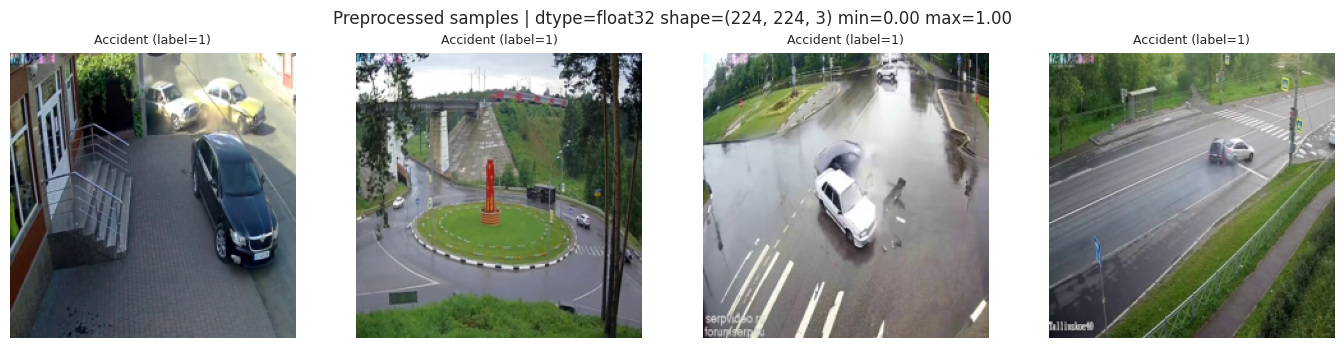

In [ ]:
def load_and_preprocess(path):
    """path (string tensor) -> float32 image in [0,1], shape (224,224,3), RGB."""
    data = tf.io.read_file(path)
    img = tf.io.decode_image(data, channels=3, expand_animations=False)   # RGB, uint8
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear", antialias=True)
    img = tf.cast(img, tf.float32) / 255.0
    return tf.clip_by_value(img, 0.0, 1.0)

# quick visual check
sample = train_df.sample(4, random_state=SEED)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, r in zip(axes, sample.itertuples()):
    im = load_and_preprocess(r.path).numpy()
    ax.imshow(im); ax.axis("off")
    ax.set_title(f"{r.class_name} (label={r.label})", fontsize=9)
plt.suptitle(f"Preprocessed samples | dtype={im.dtype} shape={im.shape} min={im.min():.2f} max={im.max():.2f}")
plt.tight_layout(); plt.show()

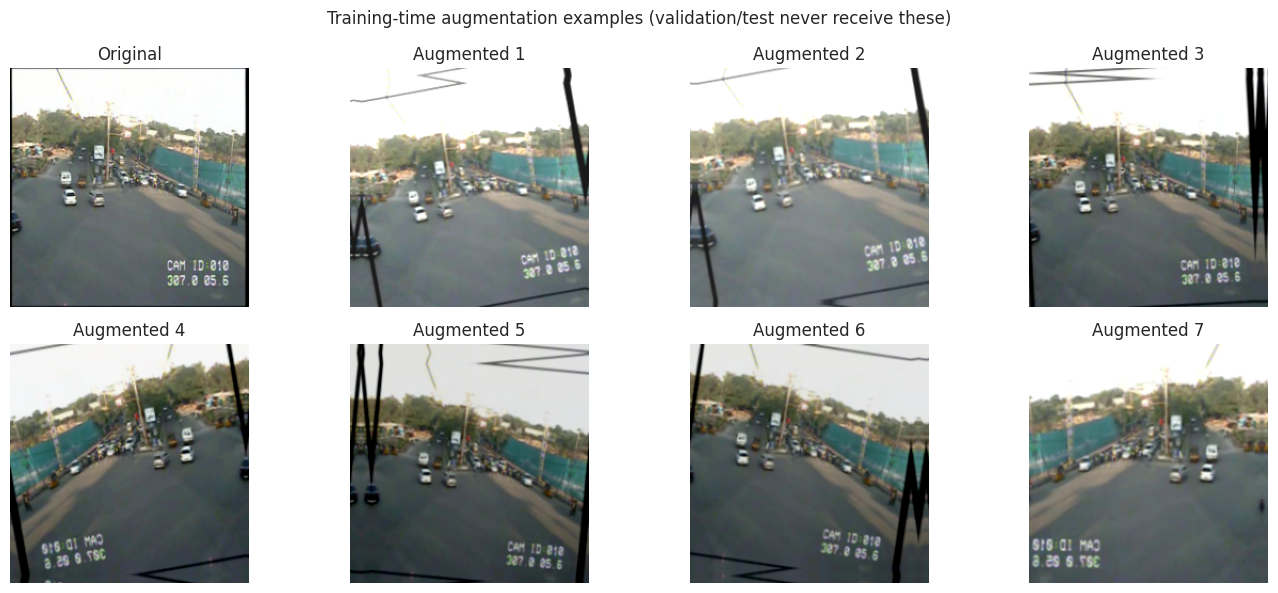

In [ ]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03, fill_mode="reflect"),
    layers.RandomZoom(0.10, fill_mode="reflect"),
    layers.RandomTranslation(0.05, 0.05, fill_mode="reflect"),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15, value_range=(0.0, 1.0)),
], name="train_augmentation")

def augment_batch(images, labels, *rest):
    images = augmenter(images, training=True)          # training=True -> random ops are active
    images = tf.clip_by_value(images, 0.0, 1.0)
    return (images, labels, *rest)

# show augmentation examples
base = load_and_preprocess(train_df.path.iloc[0])
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes[0, 0].imshow(base.numpy()); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
for i, ax in enumerate(axes.flatten()[1:]):
    aug = tf.clip_by_value(augmenter(tf.expand_dims(base, 0), training=True)[0], 0, 1)
    ax.imshow(aug.numpy()); ax.set_title(f"Augmented {i+1}"); ax.axis("off")
plt.suptitle("Training-time augmentation examples (validation/test never receive these)")
plt.tight_layout(); plt.show()

In [ ]:
# ---------- class mapping check ----------
for df_ in (train_df, val_df, test_df):
    assert (df_.class_name.map(CLASS_TO_IDX) == df_.label).all(), "Label mapping mismatch!"
print("CLASS MAPPING (used everywhere):")
for k, v in CLASS_TO_IDX.items():
    print(f"   {k:13s} -> {v}")

# ---------- class weights (computed from TRAIN labels only) ----------
cw_values = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_df.label.values)
CLASS_WEIGHTS = {0: float(cw_values[0]), 1: float(cw_values[1])}
counts = train_df.label.value_counts()
IMBALANCE_RATIO = counts.max() / max(counts.min(), 1)
USE_CLASS_WEIGHTS = IMBALANCE_RATIO > CLASS_WEIGHT_TRIGGER
print("\nCalculated class weights:", {IDX_TO_CLASS[k]: round(v, 4) for k, v in CLASS_WEIGHTS.items()})
print(f"Imbalance ratio = {IMBALANCE_RATIO:.2f} -> class weights " +
      ("WILL be applied (ratio above trigger)" if USE_CLASS_WEIGHTS else "NOT applied (dataset is reasonably balanced)"))

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training):
    paths = df.path.values.astype(str)
    labels = df.label.values.astype("float32").reshape(-1, 1)          # shape (N,1) matches model output
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (load_and_preprocess(p), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(augment_batch, num_parallel_calls=AUTOTUNE)          # augmentation ONLY here
        if USE_CLASS_WEIGHTS:
            w1, w0 = CLASS_WEIGHTS[1], CLASS_WEIGHTS[0]
            ds = ds.map(lambda x, y: (x, y, tf.where(y > 0.5, w1, w0)), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

b = next(iter(train_ds))
print("\nOne training batch -> images:", b[0].shape, "| labels:", b[1].shape,
      "| image range: [%.2f, %.2f]" % (float(tf.reduce_min(b[0])), float(tf.reduce_max(b[0]))))

# ---------- reproducibility report ----------
def print_run_info():
    print("=" * 50); print("RUN INFORMATION"); print("=" * 50)
    print("TensorFlow version :", tf.__version__)
    print("Python version     :", sys.version.split()[0])
    print("GPU availability   :", bool(gpus), f"({DEVICE})")
    print("Dataset counts     : train=%d | val=%d | test=%d" % (len(train_df), len(val_df), len(test_df)))
    print("Image size         :", IMG_SIZE, "x", IMG_SIZE)
    print("Batch size         :", BATCH_SIZE)
    print("Learning rate      :", LEARNING_RATE)
    print("Epochs (max)       :", EPOCHS)
    print("Random seed        :", SEED)
print_run_info()

CLASS MAPPING (used everywhere):
   Non Accident  -> 0
   Accident      -> 1

Calculated class weights: {'Non Accident': 0.9455, 'Accident': 1.0611}
Imbalance ratio = 1.12 -> class weights NOT applied (dataset is reasonably balanced)

One training batch -> images: (16, 224, 224, 3) | labels: (16, 1) | image range: [0.00, 1.00]
RUN INFORMATION
TensorFlow version : 2.21.0
Python version     : 3.13.15
GPU availability   : True (GPU)
Dataset counts     : train=781 | val=98 | test=100
Image size         : 224 x 224
Batch size         : 16
Learning rate      : 0.0001
Epochs (max)       : 30
Random seed        : 42


In [ ]:
def conv_bn_relu(x, filters, name, kernel=3, strides=1, separable=True):
    Conv = layers.SeparableConv2D if separable else layers.Conv2D
    x = Conv(filters, kernel, strides=strides, padding="same", use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.ReLU(name=f"{name}_relu")(x)

def cnn_feature_extractor(x):
    # Block 1: 224 -> 112 (stride-2 conv) -> 56 (pool)
    x = conv_bn_relu(x, 32, "cnn_b1_c1", strides=2, separable=False)
    x = conv_bn_relu(x, 32, "cnn_b1_c2")
    x = layers.MaxPooling2D(2, name="cnn_b1_pool")(x)
    # Block 2: 56 -> 28
    x = conv_bn_relu(x, 64, "cnn_b2_c1")
    x = conv_bn_relu(x, 64, "cnn_b2_c2")
    x = layers.MaxPooling2D(2, name="cnn_b2_pool")(x)
    # Block 3: 28 -> 14
    x = conv_bn_relu(x, 128, "cnn_b3_c1")
    x = conv_bn_relu(x, 128, "cnn_b3_c2")
    x = layers.MaxPooling2D(2, name="cnn_b3_pool")(x)
    # Block 4: stay at 14x14
    x = conv_bn_relu(x, 128, "cnn_b4_c1")
    x = conv_bn_relu(x, 128, "cnn_b4_c2")
    return x          # (None, 14, 14, 128)
print("CNN feature extractor defined.")

CNN feature extractor defined.


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class ConvBNAct(layers.Layer):
    """Conv -> BatchNorm -> (activation). kind: 'conv' (standard), 'sep' (depthwise-separable), 'dw' (depthwise)."""
    def __init__(self, filters, kernel_size=3, strides=1, dilation_rate=1, kind="sep", activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size, self.strides = filters, kernel_size, strides
        self.dilation_rate, self.kind, self.activation_name = dilation_rate, kind, activation
        common = dict(strides=strides, dilation_rate=dilation_rate, padding="same", use_bias=False)
        if kind == "conv":
            self.conv = layers.Conv2D(filters, kernel_size, **common)
        elif kind == "sep":
            self.conv = layers.SeparableConv2D(filters, kernel_size, **common)
        elif kind == "dw":
            self.conv = layers.DepthwiseConv2D(kernel_size, **common)
        else:
            raise ValueError("kind must be 'conv', 'sep' or 'dw'")
        self.bn = layers.BatchNormalization()
        self.act = layers.Activation(activation) if activation else None

    def call(self, x, training=None):
        x = self.conv(x)
        x = self.bn(x, training=training)
        return self.act(x) if self.act is not None else x

    def get_config(self):
        cfg = super().get_config()
        cfg.update(filters=self.filters, kernel_size=self.kernel_size, strides=self.strides,
                   dilation_rate=self.dilation_rate, kind=self.kind, activation=self.activation_name)
        return cfg
print("ConvBNAct helper defined.")

ConvBNAct helper defined.


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class MultiScaleFeatureModule(layers.Layer):
    def __init__(self, channels=128, branch_channels=32, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.branch_channels = channels, branch_channels
        bc = branch_channels
        self.b1 = ConvBNAct(bc, 3, kind="sep")                       # 3x3
        self.b2a = ConvBNAct(bc, 3, kind="sep")                      # 3x3 -> 3x3 = 5x5 effective
        self.b2b = ConvBNAct(bc, 3, kind="sep")
        self.b3 = ConvBNAct(bc, 3, dilation_rate=3, kind="sep")      # dilated: 7x7 effective
        self.pool = layers.AveragePooling2D(3, strides=1, padding="same")
        self.b4 = ConvBNAct(bc, 1, kind="conv")
        self.fuse = ConvBNAct(channels, 1, kind="conv")              # concat(4*bc) -> channels
        self.refine = ConvBNAct(channels, 3, kind="sep")

    def call(self, x, training=None):
        if x.shape[-1] != self.channels:
            raise ValueError(f"MultiScaleFeatureModule expects {self.channels} channels, got {x.shape[-1]}")
        y1 = self.b1(x, training=training)
        y2 = self.b2b(self.b2a(x, training=training), training=training)
        y3 = self.b3(x, training=training)
        y4 = self.b4(self.pool(x), training=training)
        y = tf.concat([y1, y2, y3, y4], axis=-1)                     # (B,H,W,4*bc)
        y = self.fuse(y, training=training)                          # (B,H,W,C)
        y = self.refine(y, training=training)                        # feature refinement
        return x + y                                                 # residual keeps gradients healthy

    def get_config(self):
        cfg = super().get_config()
        cfg.update(channels=self.channels, branch_channels=self.branch_channels)
        return cfg

_t = tf.random.normal((2, 14, 14, 128))
_o = MultiScaleFeatureModule(128)(_t, training=False)
print("MultiScaleFeatureModule:", _t.shape, "->", _o.shape); assert _o.shape == _t.shape

MultiScaleFeatureModule: (2, 14, 14, 128) -> (2, 14, 14, 128)


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class CollisionSensitiveModule(layers.Layer):
    def __init__(self, channels=128, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.local = ConvBNAct(channels, 1, kind="conv")                          # L
        self.near = ConvBNAct(channels, 3, kind="dw", activation=None)            # N  (linear neighbourhood summary)
        self.wide = ConvBNAct(channels, 3, dilation_rate=2, kind="dw", activation=None)  # G (wider neighbourhood)
        self.mix = ConvBNAct(channels, 1, kind="conv")                            # non-linear mixing of 4*C interaction channels
        self.refine = ConvBNAct(channels, 3, kind="sep")
        self.gate = layers.Conv2D(channels, 1, activation="sigmoid")              # g

    def call(self, x, training=None):
        if x.shape[-1] != self.channels:
            raise ValueError(f"CollisionSensitiveModule expects {self.channels} channels, got {x.shape[-1]}")
        L = self.local(x, training=training)
        N = self.near(L, training=training)
        G = self.wide(L, training=training)
        inter = tf.concat([L, L - N, L * N, L - G], axis=-1)       # (B,H,W,4C) interaction features
        F = self.mix(inter, training=training)                     # (B,H,W,C)
        F = self.refine(F, training=training)
        g = self.gate(F)                                           # (B,H,W,C) in (0,1)
        return x + g * F                                           # gated residual

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels); return cfg

_t = tf.random.normal((2, 14, 14, 128))
_o = CollisionSensitiveModule(128)(_t, training=False)
print("CollisionSensitiveModule:", _t.shape, "->", _o.shape); assert _o.shape == _t.shape

CollisionSensitiveModule: (2, 14, 14, 128) -> (2, 14, 14, 128)


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class SpatialRelationModule(layers.Layer):
    def __init__(self, channels=128, num_heads=4, key_dim=16, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        assert channels % num_heads == 0, "channels must be divisible by num_heads"
        self.channels, self.num_heads, self.key_dim, self.dropout_rate = channels, num_heads, key_dim, dropout
        self.value_dim = channels // num_heads
        self.q_proj = layers.Dense(num_heads * key_dim, use_bias=False)
        self.k_proj = layers.Dense(num_heads * key_dim, use_bias=False)
        self.v_proj = layers.Dense(channels, use_bias=False)
        self.o_proj = layers.Dense(channels)
        self.attn_drop = layers.Dropout(dropout)
        self.norm = layers.LayerNormalization(epsilon=1e-5)

    def build(self, input_shape):
        h, w, c = int(input_shape[1]), int(input_shape[2]), int(input_shape[3])
        if c != self.channels:
            raise ValueError(f"SpatialRelationModule expects {self.channels} channels, got {c}")
        self.h, self.w = h, w
        self.pos_embedding = self.add_weight(name="pos_embedding", shape=(1, h, w, c),
                                             initializer=keras.initializers.RandomNormal(stddev=0.02),
                                             trainable=True)
        super().build(input_shape)

    def call(self, x, training=None):
        n = self.h * self.w
        t = tf.reshape(x + self.pos_embedding, (-1, n, self.channels))                    # (B,N,C)
        q = tf.reshape(self.q_proj(t), (-1, n, self.num_heads, self.key_dim))             # (B,N,H,dk)
        k = tf.reshape(self.k_proj(t), (-1, n, self.num_heads, self.key_dim))
        v = tf.reshape(self.v_proj(t), (-1, n, self.num_heads, self.value_dim))           # (B,N,H,dv)
        scores = tf.einsum("bnhd,bmhd->bhnm", q, k) / (float(self.key_dim) ** 0.5)        # (B,H,N,N)
        attn = tf.nn.softmax(scores, axis=-1)                                             # relation strengths
        attn = self.attn_drop(attn, training=training)
        ctx = tf.einsum("bhnm,bmhd->bnhd", attn, v)                                       # (B,N,H,dv)
        ctx = tf.reshape(ctx, (-1, n, self.channels))                                     # concat heads
        ctx = self.o_proj(ctx)
        ctx = tf.reshape(ctx, (-1, self.h, self.w, self.channels))
        return self.norm(x + ctx)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(channels=self.channels, num_heads=self.num_heads, key_dim=self.key_dim, dropout=self.dropout_rate)
        return cfg

_t = tf.random.normal((2, 14, 14, 128))
_o = SpatialRelationModule(128)(_t, training=False)
print("SpatialRelationModule:", _t.shape, "->", _o.shape); assert _o.shape == _t.shape

SpatialRelationModule: (2, 14, 14, 128) -> (2, 14, 14, 128)


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class AttentionModule(layers.Layer):
    def __init__(self, channels=128, reduction=8, spatial_kernel=7, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.reduction, self.spatial_kernel = channels, reduction, spatial_kernel
        self.fc1 = layers.Dense(max(channels // reduction, 4), activation="relu")     # shared MLP
        self.fc2 = layers.Dense(channels)
        self.spatial_conv = layers.Conv2D(1, spatial_kernel, padding="same", activation="sigmoid")

    def call(self, x, training=None):
        avg = tf.reduce_mean(x, axis=[1, 2])                                          # (B,C)
        mx = tf.reduce_max(x, axis=[1, 2])                                            # (B,C)
        channel_att = tf.sigmoid(self.fc2(self.fc1(avg)) + self.fc2(self.fc1(mx)))    # (B,C)
        x = x * channel_att[:, None, None, :]
        s = tf.concat([tf.reduce_mean(x, axis=-1, keepdims=True),
                       tf.reduce_max(x, axis=-1, keepdims=True)], axis=-1)            # (B,H,W,2)
        spatial_att = self.spatial_conv(s)                                            # (B,H,W,1)
        return x * spatial_att

    def get_config(self):
        cfg = super().get_config()
        cfg.update(channels=self.channels, reduction=self.reduction, spatial_kernel=self.spatial_kernel)
        return cfg

_t = tf.random.normal((2, 14, 14, 128))
_o = AttentionModule(128)(_t, training=False)
print("AttentionModule:", _t.shape, "->", _o.shape); assert _o.shape == _t.shape

AttentionModule: (2, 14, 14, 128) -> (2, 14, 14, 128)


In [ ]:
@keras.utils.register_keras_serializable(package="CSRN")
class FeatureFusionModule(layers.Layer):
    def __init__(self, out_channels=128, align_channels=64, num_inputs=4, **kwargs):
        super().__init__(**kwargs)
        self.out_channels, self.align_channels, self.num_inputs = out_channels, align_channels, num_inputs
        self.align = [ConvBNAct(align_channels, 1, kind="conv") for _ in range(num_inputs)]
        self.mix = ConvBNAct(out_channels, 1, kind="conv")
        self.refine = ConvBNAct(out_channels, 3, kind="sep")

    def call(self, inputs, training=None):
        if len(inputs) != self.num_inputs:
            raise ValueError(f"FeatureFusionModule expects {self.num_inputs} inputs, got {len(inputs)}")
        aligned = [a(t, training=training) for a, t in zip(self.align, inputs)]        # 4 x (B,H,W,64)
        x = tf.concat(aligned, axis=-1)                                                # (B,H,W,256)
        x = self.mix(x, training=training)                                             # (B,H,W,128)
        return x + self.refine(x, training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(out_channels=self.out_channels, align_channels=self.align_channels, num_inputs=self.num_inputs)
        return cfg

_ts = [tf.random.normal((2, 14, 14, 128)) for _ in range(4)]
_o = FeatureFusionModule()(_ts, training=False)
print("FeatureFusionModule: 4 x", _ts[0].shape, "->", _o.shape); assert _o.shape == (2, 14, 14, 128)

FeatureFusionModule: 4 x (2, 14, 14, 128) -> (2, 14, 14, 128)


In [ ]:
VARIANT_FLAGS = {          # (multi_scale, collision, spatial_relation, attention+fusion)
    "A": (False, False, False, False),
    "B": (True,  False, False, False),
    "C": (True,  True,  False, False),
    "D": (True,  True,  True,  False),
    "E": (True,  True,  True,  True),
}
VARIANT_DESCRIPTION = {
    "A": "CNN baseline", "B": "CNN + Multi-Scale", "C": "CNN + MS + Collision-Sensitive",
    "D": "CNN + MS + CS + Spatial Relation", "E": "Full CSRN", "SIMPLE": "Plain simple CNN",
}

def mlp_head(x, dense_units=64, dropout=0.4):
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(dense_units, activation="relu", name="mlp_dense_1")(x)
    x = layers.Dropout(dropout, name="mlp_dropout")(x)
    return layers.Dense(1, activation="sigmoid", name="accident_probability")(x)      # P(Accident)

def build_csrn_model(variant="E", img_shape=IMG_SHAPE, dense_units=64, dropout=0.4):
    use_ms, use_cs, use_sr, use_att_fusion = VARIANT_FLAGS[variant]
    inp = keras.Input(shape=img_shape, name="input_image")
    x = cnn_feature_extractor(inp)                                                    # (14,14,128)
    f_ms = f_cs = f_sr = None
    if use_ms:
        f_ms = MultiScaleFeatureModule(128, name="multi_scale")(x);          x = f_ms
    if use_cs:
        f_cs = CollisionSensitiveModule(128, name="collision_sensitive")(x); x = f_cs
    if use_sr:
        f_sr = SpatialRelationModule(128, name="spatial_relation")(x);       x = f_sr
    if use_att_fusion:
        f_att = AttentionModule(128, name="attention")(f_sr)
        x = FeatureFusionModule(128, name="feature_fusion")([f_ms, f_cs, f_sr, f_att])
    out = mlp_head(x, dense_units, dropout)
    return keras.Model(inp, out, name="CSRN" if variant == "E" else f"CSRN_variant_{variant}")

def build_simple_cnn(img_shape=IMG_SHAPE, dense_units=64, dropout=0.4):
    """Plain CNN baseline: 4 x (Conv-BN-ReLU-MaxPool) -> GAP -> MLP. No CSRN modules."""
    inp = keras.Input(shape=img_shape, name="input_image")
    x = inp
    for i, f in enumerate([32, 64, 128, 128]):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False, name=f"simple_conv{i+1}")(x)
        x = layers.BatchNormalization(name=f"simple_bn{i+1}")(x)
        x = layers.ReLU(name=f"simple_relu{i+1}")(x)
        x = layers.MaxPooling2D(2, name=f"simple_pool{i+1}")(x)
    return keras.Model(inp, mlp_head(x, dense_units, dropout), name="Simple_CNN")

def build_by_name(variant):
    return build_simple_cnn() if variant == "SIMPLE" else build_csrn_model(variant)

# ---- build the full CSRN and verify shapes
set_global_seed(SEED)
model = build_csrn_model("E")
_dummy = tf.random.uniform((2, 224, 224, 3))
_pred = model(_dummy, training=False)
assert _pred.shape == (2, 1) and bool(tf.reduce_all((_pred >= 0) & (_pred <= 1))), "Unexpected output!"
for lname in ["cnn_b4_c2_relu", "multi_scale", "collision_sensitive", "spatial_relation", "attention",
              "feature_fusion", "gap", "mlp_dense_1", "accident_probability"]:
    print(f"{lname:24s} output shape: {model.get_layer(lname).output.shape}")
print("\nShape check passed. Output is a probability in [0,1] with shape", _pred.shape)

cnn_b4_c2_relu           output shape: (None, 14, 14, 128)
multi_scale              output shape: (None, 14, 14, 128)
collision_sensitive      output shape: (None, 14, 14, 128)
spatial_relation         output shape: (None, 14, 14, 128)
attention                output shape: (None, 14, 14, 128)
feature_fusion           output shape: (None, 14, 14, 128)
gap                      output shape: (None, 128)
mlp_dense_1              output shape: (None, 64)
accident_probability     output shape: (None, 1)

Shape check passed. Output is a probability in [0,1] with shape (2, 1)


In [ ]:
model.summary()

Model: "CSRN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c1_conv      │ (None, 112, 112,  │        864 │ input_image[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c1_bn        │ (None, 112, 112,  │        128 │ cnn_b1_c1_conv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c1_relu      │ (None, 112, 112,  │          0 │ cnn_b1_c1_bn[0][… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c2_conv      │ (None, 112, 112,  │      1,312 │ cnn_b1_c1_relu[0… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c2_bn        │ (None, 112, 112,  │        128 │ cnn_b1_c2_conv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_c2_relu      │ (None, 112, 112,  │          0 │ cnn_b1_c2_bn[0][… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b1_pool         │ (None, 56, 56,    │          0 │ cnn_b1_c2_relu[0… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c1_conv      │ (None, 56, 56,    │      2,336 │ cnn_b1_pool[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c1_bn        │ (None, 56, 56,    │        256 │ cnn_b2_c1_conv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c1_relu      │ (None, 56, 56,    │          0 │ cnn_b2_c1_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c2_conv      │ (None, 56, 56,    │      4,672 │ cnn_b2_c1_relu[0… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c2_bn        │ (None, 56, 56,    │        256 │ cnn_b2_c2_conv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_c2_relu      │ (None, 56, 56,    │          0 │ cnn_b2_c2_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b2_pool         │ (None, 28, 28,    │          0 │ cnn_b2_c2_relu[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b3_c1_conv      │ (None, 28, 28,    │      8,768 │ cnn_b2_pool[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_b3_c1_bn        │ (None, 28, 28,    │        512 │ cnn_b3_c1_conv[0

 Total params: 423,348 (1.61 MB)

 Trainable params: 418,804 (1.60 MB)

 Non-trainable params: 4,544 (17.75 KB)

In [ ]:
def count_parameters(m):
    trainable = int(sum(np.prod(w.shape) for w in m.trainable_weights))
    non_trainable = int(sum(np.prod(w.shape) for w in m.non_trainable_weights))
    total = trainable + non_trainable
    return dict(total=total, trainable=trainable, non_trainable=non_trainable, size_mb=total * 4 / (1024 ** 2))

def measure_inference_time(m, n_warmup=5, n_runs=30, batch=1):
    x = tf.random.uniform((batch, IMG_SIZE, IMG_SIZE, 3))
    for _ in range(n_warmup):
        m(x, training=False)
    t0 = time.perf_counter()
    for _ in range(n_runs):
        _ = m(x, training=False).numpy()
    return (time.perf_counter() - t0) / n_runs / batch * 1000.0          # ms per image

PARAMS = count_parameters(model)
print("Total parameters         : {:,}".format(PARAMS["total"]))
print("Trainable parameters     : {:,}".format(PARAMS["trainable"]))
print("Non-trainable parameters : {:,}  (BatchNorm moving statistics)".format(PARAMS["non_trainable"]))
print("Approx. model size       : {:.2f} MB (float32)".format(PARAMS["size_mb"]))
print("Check vs Keras count_params():", model.count_params(), "(should equal total)")

print("\nParameters per CSRN module:")
for lname in ["multi_scale", "collision_sensitive", "spatial_relation", "attention", "feature_fusion"]:
    print(f"   {lname:22s} {model.get_layer(lname).count_params():>10,}")

INF_MS_1 = measure_inference_time(model, batch=1)
INF_MS_16 = measure_inference_time(model, batch=16, n_runs=10)
print(f"\nInference time on {DEVICE}: {INF_MS_1:.1f} ms/image (batch=1) | {INF_MS_16:.1f} ms/image (batch=16)")

Total parameters         : 423,348
Trainable parameters     : 418,804
Non-trainable parameters : 4,544  (BatchNorm moving statistics)
Approx. model size       : 1.61 MB (float32)
Check vs Keras count_params(): 423348 (should equal total)

Parameters per CSRN module:
   multi_scale                56,736
   collision_sensitive       120,832
   spatial_relation           74,624
   attention                   4,339
   feature_fusion             85,120

Inference time on GPU: 237.9 ms/image (batch=1) | 7.8 ms/image (batch=16)


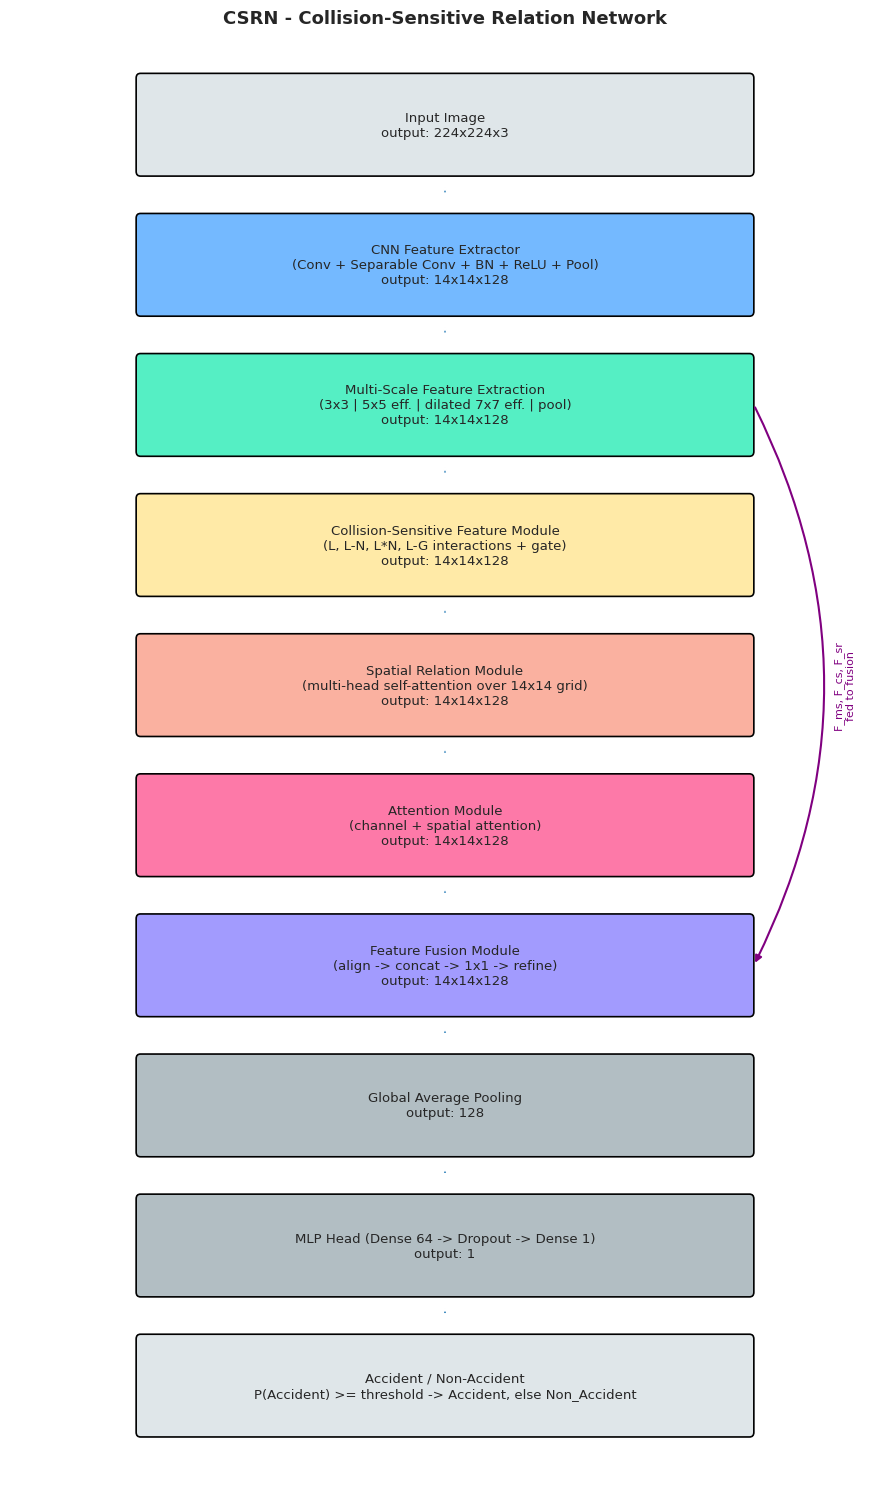

Keras plot_model saved too.


In [ ]:
def draw_architecture(m, save_path):
    def shp(name):
        try:
            return "x".join(str(d) for d in m.get_layer(name).output.shape[1:])
        except Exception:
            return "?"
    blocks = [
        ("Input Image", "input_image", "#dfe6e9"),
        ("CNN Feature Extractor\n(Conv + Separable Conv + BN + ReLU + Pool)", "cnn_b4_c2_relu", "#74b9ff"),
        ("Multi-Scale Feature Extraction\n(3x3 | 5x5 eff. | dilated 7x7 eff. | pool)", "multi_scale", "#55efc4"),
        ("Collision-Sensitive Feature Module\n(L, L-N, L*N, L-G interactions + gate)", "collision_sensitive", "#ffeaa7"),
        ("Spatial Relation Module\n(multi-head self-attention over 14x14 grid)", "spatial_relation", "#fab1a0"),
        ("Attention Module\n(channel + spatial attention)", "attention", "#fd79a8"),
        ("Feature Fusion Module\n(align -> concat -> 1x1 -> refine)", "feature_fusion", "#a29bfe"),
        ("Global Average Pooling", "gap", "#b2bec3"),
        ("MLP Head (Dense 64 -> Dropout -> Dense 1)", "accident_probability", "#b2bec3"),
        ("Accident / Non-Accident", None, "#dfe6e9"),
    ]
    fig, ax = plt.subplots(figsize=(9, 15))
    ax.set_xlim(0, 10); ax.set_ylim(0, len(blocks) * 1.5 + 0.5); ax.axis("off")
    for i, (label, lname, color) in enumerate(blocks):
        y = (len(blocks) - 1 - i) * 1.5 + 0.5
        ax.add_patch(FancyBboxPatch((1.5, y), 7, 1.0, boxstyle="round,pad=0.05", fc=color, ec="black", lw=1.2))
        extra = f"\noutput: {shp(lname)}" if lname else "\nP(Accident) >= threshold -> Accident, else Non_Accident"
        ax.text(5, y + 0.5, label + extra, ha="center", va="center", fontsize=9.5)
        if i < len(blocks) - 1:
            ax.annotate("", xy=(5, y - 0.12), xytext=(5, y - 0.38), arrowprops=dict(arrowstyle="-|>", lw=1.5))
    # skip connections into the fusion module
    fy = (len(blocks) - 1 - 6) * 1.5 + 0.5 + 0.5
    ax.annotate("", xy=(8.55, fy), xytext=(8.55, (len(blocks) - 1 - 2) * 1.5 + 1.0),
                arrowprops=dict(arrowstyle="-|>", color="purple", lw=1.5, connectionstyle="arc3,rad=-0.25"))
    ax.text(9.6, (fy + (len(blocks) - 1 - 2) * 1.5 + 1.0) / 2, "F_ms, F_cs, F_sr\nfed to fusion",
            rotation=90, ha="center", va="center", fontsize=8, color="purple")
    ax.set_title("CSRN - Collision-Sensitive Relation Network", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

draw_architecture(model, os.path.join(OUTPUT_DIR, "architecture.png"))
try:
    keras.utils.plot_model(model, to_file=os.path.join(OUTPUT_DIR, "architecture_keras_plot.png"),
                           show_shapes=True, show_layer_names=True, dpi=70)
    print("Keras plot_model saved too.")
except Exception as e:
    print("plot_model skipped (Graphviz/pydot not available):", type(e).__name__)

In [ ]:
def build_optimizer(lr=LEARNING_RATE):
    try:
        return keras.optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY)
    except Exception:
        print("AdamW not available in this TF version -> using Adam.")
        return keras.optimizers.Adam(learning_rate=lr)

def compile_model(m, lr=LEARNING_RATE):
    m.compile(optimizer=build_optimizer(lr),
              loss=keras.losses.BinaryCrossentropy(),
              metrics=[keras.metrics.BinaryAccuracy(name="accuracy"),
                       keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m

def get_lr(m):
    lr = m.optimizer.learning_rate
    for fn in (lambda: float(keras.backend.get_value(lr)), lambda: float(lr.numpy()), lambda: float(np.array(lr))):
        try:
            return fn()
        except Exception:
            continue
    return float("nan")

class LRLogger(keras.callbacks.Callback):
    """Records and prints the learning rate used in each epoch (placed BEFORE ReduceLROnPlateau)."""
    def __init__(self):
        super().__init__(); self.lrs = []
    def on_epoch_end(self, epoch, logs=None):
        lr = get_lr(self.model); self.lrs.append(lr)
        print(f"    -> epoch {epoch+1}: learning rate = {lr:.2e}")

def make_callbacks(tag):
    ckpt_path = os.path.join(CKPT_DIR, f"{tag}.weights.h5")
    lr_logger = LRLogger()
    cbs = [lr_logger,
           keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", mode="min",
                                           save_best_only=True, save_weights_only=True, verbose=1),
           keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=LR_FACTOR, patience=LR_PATIENCE,
                                             min_lr=MIN_LR, verbose=1),
           keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                                         restore_best_weights=True, verbose=1)]
    return cbs, ckpt_path, lr_logger

compile_model(model)
print("Model compiled. Loss = BinaryCrossentropy | optimizer =", type(model.optimizer).__name__,
      "| lr =", LEARNING_RATE)

Model compiled. Loss = BinaryCrossentropy | optimizer = AdamW | lr = 0.0001


In [ ]:
set_global_seed(SEED)
callbacks, BEST_CKPT_PATH, lr_logger = make_callbacks("CSRN_E")
t_start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
TRAIN_SECONDS = time.time() - t_start
print(f"\nTraining finished in {TRAIN_SECONDS/60:.1f} min | epochs run: {len(history.history['loss'])}")

Epoch 1/30
    -> epoch 1: learning rate = 1.00e-04

Epoch 1: val_loss improved from None to 0.69143, saving model to /content/csrn_results/checkpoints/CSRN_E.weights.h5

Epoch 1: finished saving model to /content/csrn_results/checkpoints/CSRN_E.weights.h5
49/49 - 140s - 3s/step - accuracy: 0.5455 - auc: 0.5418 - loss: 0.7559 - precision: 0.5172 - recall: 0.5299 - val_accuracy: 0.5306 - val_auc: 0.5000 - val_loss: 0.6914 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
    -> epoch 2: learning rate = 1.00e-04

Epoch 2: val_loss did not improve from 0.69143
49/49 - 22s - 441ms/step - accuracy: 0.5314 - auc: 0.5511 - loss: 0.7365 - precision: 0.5032 - recall: 0.4212 - val_accuracy: 0.4694 - val_auc: 0.5000 - val_loss: 0.6960 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
    -> epoch 3: learning rate = 1.00e-04

Epoch 3: val_loss did not improve from 0.69143
49/49 - 43s - 871ms/step - accuracy: 0.5531 - auc: 

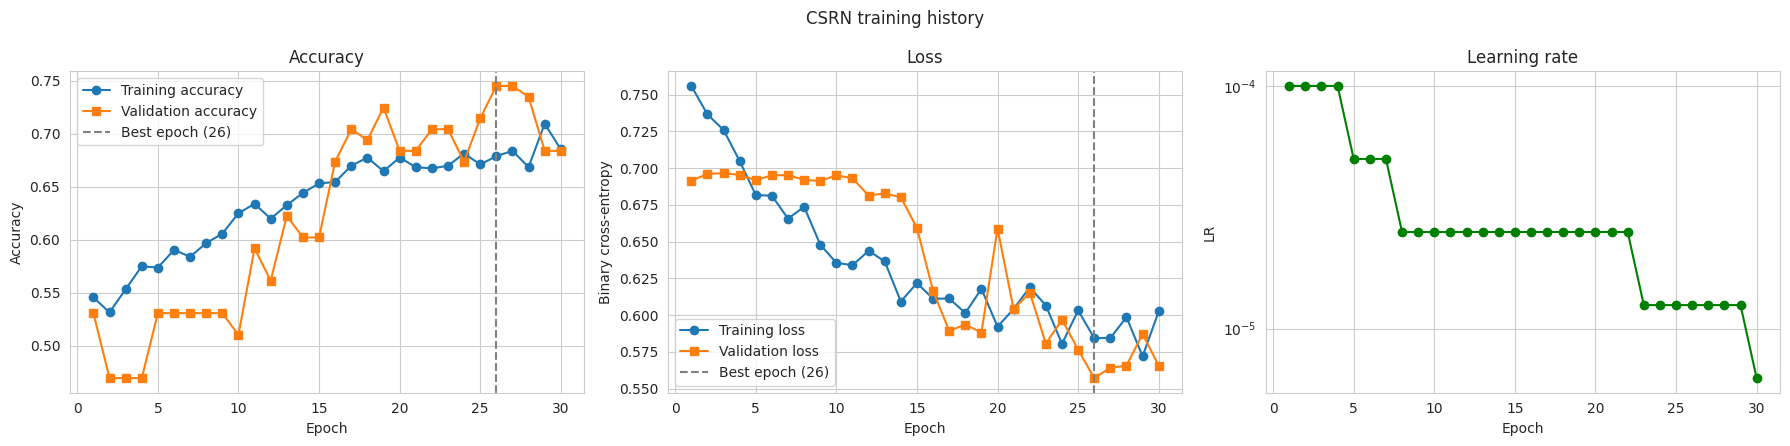

Best epoch (lowest val_loss): 26
  train acc=0.6786 | val acc=0.7449 | gap=-0.0663
  train loss=0.5843 | val loss=0.5571
  Diagnosis: no strong sign of over/under-fitting at the best epoch (curves are reasonably close).


In [ ]:
def plot_history(hist, lrs, save_path=None, title="CSRN training history"):
    h = hist.history
    ep = np.arange(1, len(h["loss"]) + 1)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    ax[0].plot(ep, h["accuracy"], "o-", label="Training accuracy")
    ax[0].plot(ep, h["val_accuracy"], "s-", label="Validation accuracy")
    ax[0].axvline(best_ep, color="gray", ls="--", label=f"Best epoch ({best_ep})")
    ax[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy"); ax[0].legend()
    ax[1].plot(ep, h["loss"], "o-", label="Training loss")
    ax[1].plot(ep, h["val_loss"], "s-", label="Validation loss")
    ax[1].axvline(best_ep, color="gray", ls="--", label=f"Best epoch ({best_ep})")
    ax[1].set(title="Loss", xlabel="Epoch", ylabel="Binary cross-entropy"); ax[1].legend()
    ax[2].plot(ep[:len(lrs)], lrs, "o-", color="green"); ax[2].set_yscale("log")
    ax[2].set(title="Learning rate", xlabel="Epoch", ylabel="LR")
    plt.suptitle(title); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return best_ep

BEST_EPOCH = plot_history(history, lr_logger.lrs, os.path.join(OUTPUT_DIR, "training_history.png"))
h = history.history; i = BEST_EPOCH - 1
GAP_ACC = h["accuracy"][i] - h["val_accuracy"][i]
print(f"Best epoch (lowest val_loss): {BEST_EPOCH}")
print(f"  train acc={h['accuracy'][i]:.4f} | val acc={h['val_accuracy'][i]:.4f} | gap={GAP_ACC:+.4f}")
print(f"  train loss={h['loss'][i]:.4f} | val loss={h['val_loss'][i]:.4f}")
if h["accuracy"][i] < 0.70 and h["val_accuracy"][i] < 0.70:
    print("  Diagnosis: possible UNDERFITTING (both accuracies are low).")
elif GAP_ACC > 0.10:
    print("  Diagnosis: possible OVERFITTING (training accuracy is clearly higher than validation accuracy).")
else:
    print("  Diagnosis: no strong sign of over/under-fitting at the best epoch (curves are reasonably close).")

In [ ]:
best_model = build_csrn_model("E")
best_model.load_weights(BEST_CKPT_PATH)
compile_model(best_model)
val_res = best_model.evaluate(val_ds, verbose=0, return_dict=True)
print("Best CSRN checkpoint loaded:", BEST_CKPT_PATH)
print("Validation metrics of the loaded model:", {k: round(float(v), 4) for k, v in val_res.items()})

Best CSRN checkpoint loaded: /content/csrn_results/checkpoints/CSRN_E.weights.h5
Validation metrics of the loaded model: {'accuracy': 0.7449, 'auc': 0.7814, 'loss': 0.5571, 'precision': 0.7692, 'recall': 0.6522}


In [ ]:
def predict_probs(m, ds):
    return m.predict(ds, verbose=0).ravel()

def metrics_at(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return dict(threshold=float(thr),
                accuracy=accuracy_score(y_true, pred),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                f1=f1_score(y_true, pred, zero_division=0),
                f2=fbeta_score(y_true, pred, beta=2, zero_division=0),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

def threshold_table(y_true, prob, grid=THRESHOLD_GRID):
    return pd.DataFrame([metrics_at(y_true, prob, t) for t in grid])

def select_threshold(y_val, p_val, metric=THRESHOLD_METRIC):
    tab = threshold_table(y_val, p_val)
    tab["dist_to_0.5"] = (tab.threshold - 0.5).abs()
    best = tab.sort_values([metric, "dist_to_0.5"], ascending=[False, True]).iloc[0]
    return float(best.threshold), tab.drop(columns="dist_to_0.5")

def safe_auc(y, p):
    return float(roc_auc_score(y, p)) if len(np.unique(y)) > 1 else float("nan")

y_val, y_test = val_df.label.values, test_df.label.values
val_probs = predict_probs(best_model, val_ds)          # used ONLY to choose the threshold
test_probs = predict_probs(best_model, test_ds)        # test predictions: computed once, reused below
assert len(val_probs) == len(y_val) and len(test_probs) == len(y_test)

BEST_THRESHOLD, val_thr_table = select_threshold(y_val, val_probs)
print(f"Operating threshold chosen on VALIDATION data (metric={THRESHOLD_METRIC}): {BEST_THRESHOLD:.2f}")

test_pred_05 = (test_probs >= 0.5).astype(int)
test_pred = (test_probs >= BEST_THRESHOLD).astype(int)
TEST_AUC = safe_auc(y_test, test_probs)
TEST_AP = float(average_precision_score(y_test, test_probs))
m05 = metrics_at(y_test, test_probs, 0.5)
mbest = metrics_at(y_test, test_probs, BEST_THRESHOLD)

print("\n=== TEST RESULTS ===")
print(f"{'':22s}{'thr=0.50':>12s}{'thr=%.2f (val-selected)' % BEST_THRESHOLD:>26s}")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"{k:22s}{m05[k]:12.4f}{mbest[k]:26.4f}")
print(f"{'ROC-AUC':22s}{TEST_AUC:12.4f}{TEST_AUC:26.4f}   (threshold independent)")

print(f"\nClassification report (threshold = {BEST_THRESHOLD:.2f}):\n")
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
report_dict = classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=4,
                                    output_dict=True, zero_division=0)

Operating threshold chosen on VALIDATION data (metric=f1): 0.45

=== TEST RESULTS ===
                          thr=0.50   thr=0.45 (val-selected)
accuracy                    0.6600                    0.6700
precision                   0.6757                    0.6667
recall                      0.5319                    0.5957
f1                          0.5952                    0.6292
ROC-AUC                     0.7503                    0.7503   (threshold independent)

Classification report (threshold = 0.45):

              precision    recall  f1-score   support

Non Accident     0.6724    0.7358    0.7027        53
    Accident     0.6667    0.5957    0.6292        47

    accuracy                         0.6700       100
   macro avg     0.6695    0.6658    0.6660       100
weighted avg     0.6697    0.6700    0.6682       100



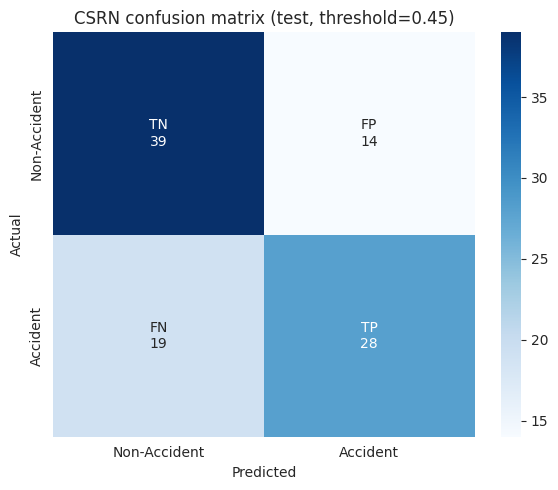

TN=39  FP=14  FN=19  TP=28
Missed accidents (FN): 19 of 47 real accident images (40.4%)
False alarms (FP)    : 14 of 53 normal images (26.4%)


In [ ]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
annot = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True,
            xticklabels=["Non-Accident", "Accident"], yticklabels=["Non-Accident", "Accident"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"CSRN confusion matrix (test, threshold={BEST_THRESHOLD:.2f})")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=200, bbox_inches="tight"); plt.show()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Missed accidents (FN): {fn} of {fn + tp} real accident images ({fn / max(fn + tp, 1):.1%})")
print(f"False alarms (FP)    : {fp} of {fp + tn} normal images ({fp / max(fp + tn, 1):.1%})")

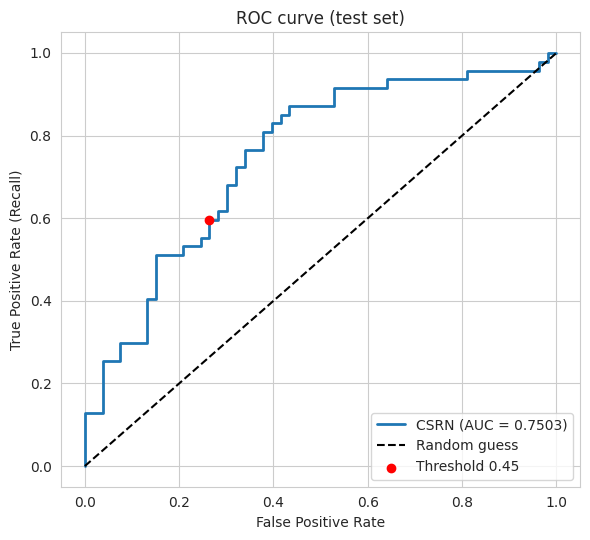

ROC-AUC (computed from test predictions): 0.7503


In [ ]:
fpr, tpr, roc_thr = roc_curve(y_test, test_probs)
plt.figure(figsize=(6, 5.5))
plt.plot(fpr, tpr, lw=2, label=f"CSRN (AUC = {TEST_AUC:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.scatter([fp / max(fp + tn, 1)], [tp / max(tp + fn, 1)], c="red", zorder=5, label=f"Threshold {BEST_THRESHOLD:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curve (test set)"); plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=200, bbox_inches="tight"); plt.show()
print(f"ROC-AUC (computed from test predictions): {TEST_AUC:.4f}")

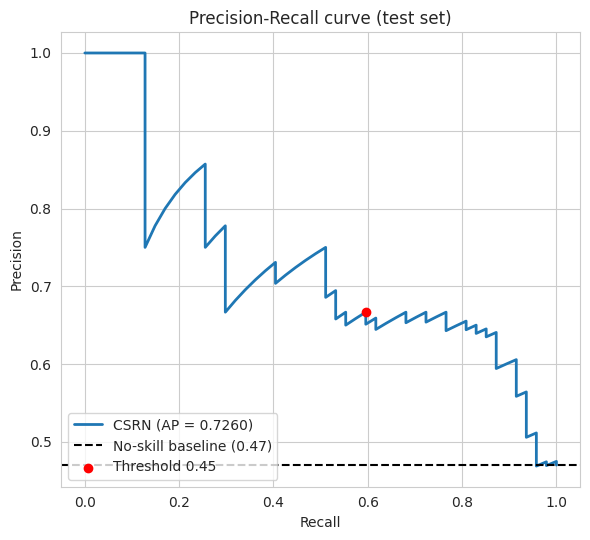

Average Precision (computed from test predictions): 0.7260


In [ ]:
prec, rec, _ = precision_recall_curve(y_test, test_probs)
prevalence = float(np.mean(y_test))
plt.figure(figsize=(6, 5.5))
plt.plot(rec, prec, lw=2, label=f"CSRN (AP = {TEST_AP:.4f})")
plt.axhline(prevalence, color="k", ls="--", label=f"No-skill baseline ({prevalence:.2f})")
plt.scatter([tp / max(tp + fn, 1)], [tp / max(tp + fp, 1)], c="red", zorder=5, label=f"Threshold {BEST_THRESHOLD:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve (test set)")
plt.legend(loc="lower left"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=200, bbox_inches="tight"); plt.show()
print(f"Average Precision (computed from test predictions): {TEST_AP:.4f}")

VALIDATION set (used to choose the threshold):
 threshold  precision  recall     f1  accuracy  tp  fp  fn  tn
      0.10     0.4792  1.0000 0.6479    0.4898  46  50   0   2
      0.15     0.4787  0.9783 0.6429    0.4898  45  49   1   3
      0.20     0.5125  0.8913 0.6508    0.5510  41  39   5  13
      0.25     0.5909  0.8478 0.6964    0.6531  39  27   7  25
      0.30     0.6230  0.8261 0.7103    0.6837  38  23   8  29
      0.35     0.6545  0.7826 0.7129    0.7041  36  19  10  33
      0.40     0.6735  0.7174 0.6947    0.7041  33  16  13  36
      0.45     0.7442  0.6957 0.7191    0.7449  32  11  14  41
      0.50     0.7692  0.6522 0.7059    0.7449  30   9  16  43
      0.55     0.8333  0.5435 0.6579    0.7347  25   5  21  47
      0.60     0.8462  0.4783 0.6111    0.7143  22   4  24  48
      0.65     0.8889  0.3478 0.5000    0.6735  16   2  30  50
      0.70     0.9231  0.2609 0.4068    0.6429  12   1  34  51
      0.75     0.8889  0.1739 0.2909    0.6020   8   1  38  51
      0.

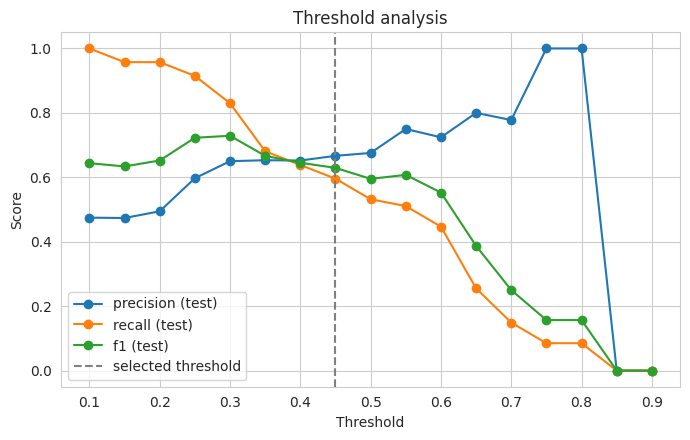

In [ ]:
test_thr_table = threshold_table(y_test, test_probs)
test_thr_table.to_csv(os.path.join(OUTPUT_DIR, "threshold_results.csv"), index=False)
val_thr_table.to_csv(os.path.join(OUTPUT_DIR, "threshold_results_validation.csv"), index=False)

cols = ["threshold", "precision", "recall", "f1", "accuracy", "tp", "fp", "fn", "tn"]
print("VALIDATION set (used to choose the threshold):")
print(val_thr_table[cols].round(4).to_string(index=False))
print("\nTEST set (reporting only):")
print(test_thr_table[cols].round(4).to_string(index=False))
print(f"\n>>> Selected operating threshold (from validation, metric={THRESHOLD_METRIC}): {BEST_THRESHOLD:.2f}")

plt.figure(figsize=(7, 4.5))
for c in ["precision", "recall", "f1"]:
    plt.plot(test_thr_table.threshold, test_thr_table[c], "o-", label=f"{c} (test)")
plt.axvline(BEST_THRESHOLD, color="gray", ls="--", label="selected threshold")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Threshold analysis"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_analysis.png"), dpi=200, bbox_inches="tight"); plt.show()

{'TN': 39, 'TP': 28, 'FN': 19, 'FP': 14}


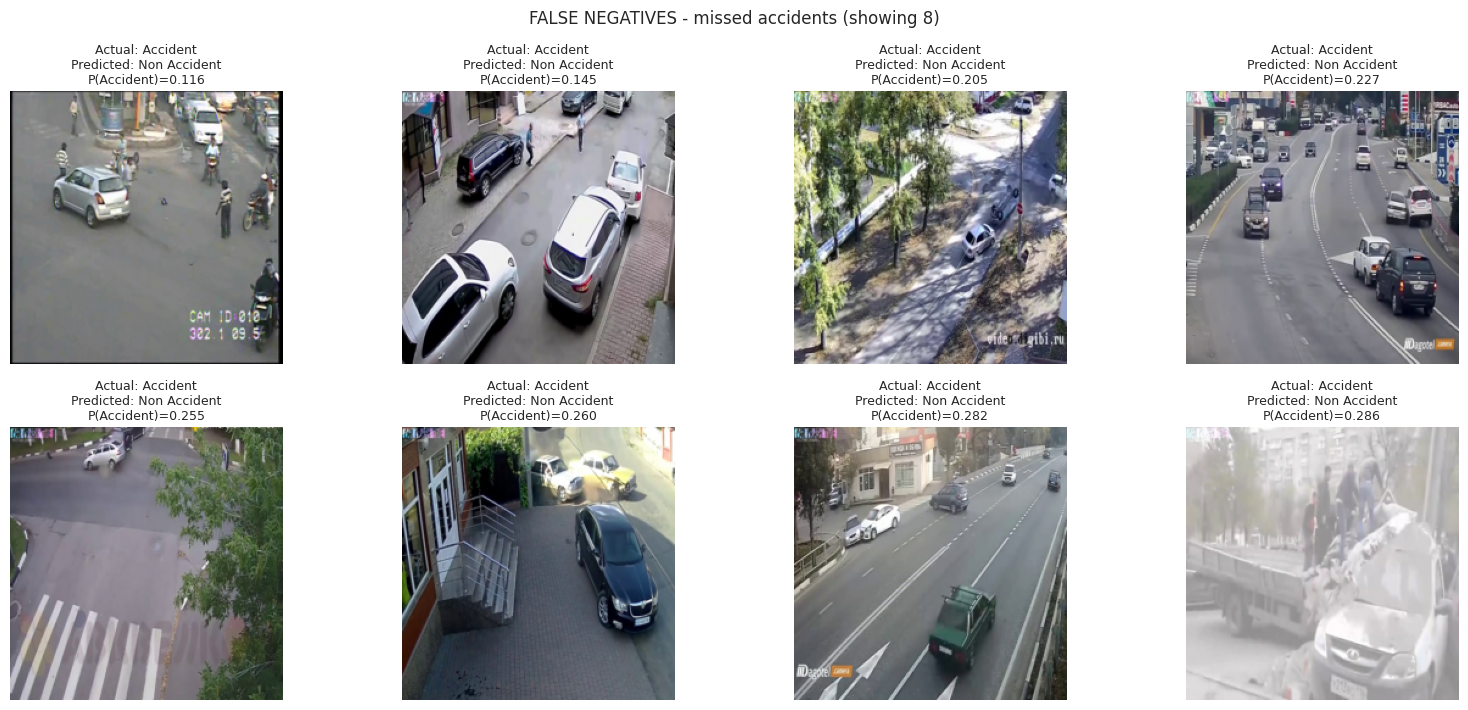

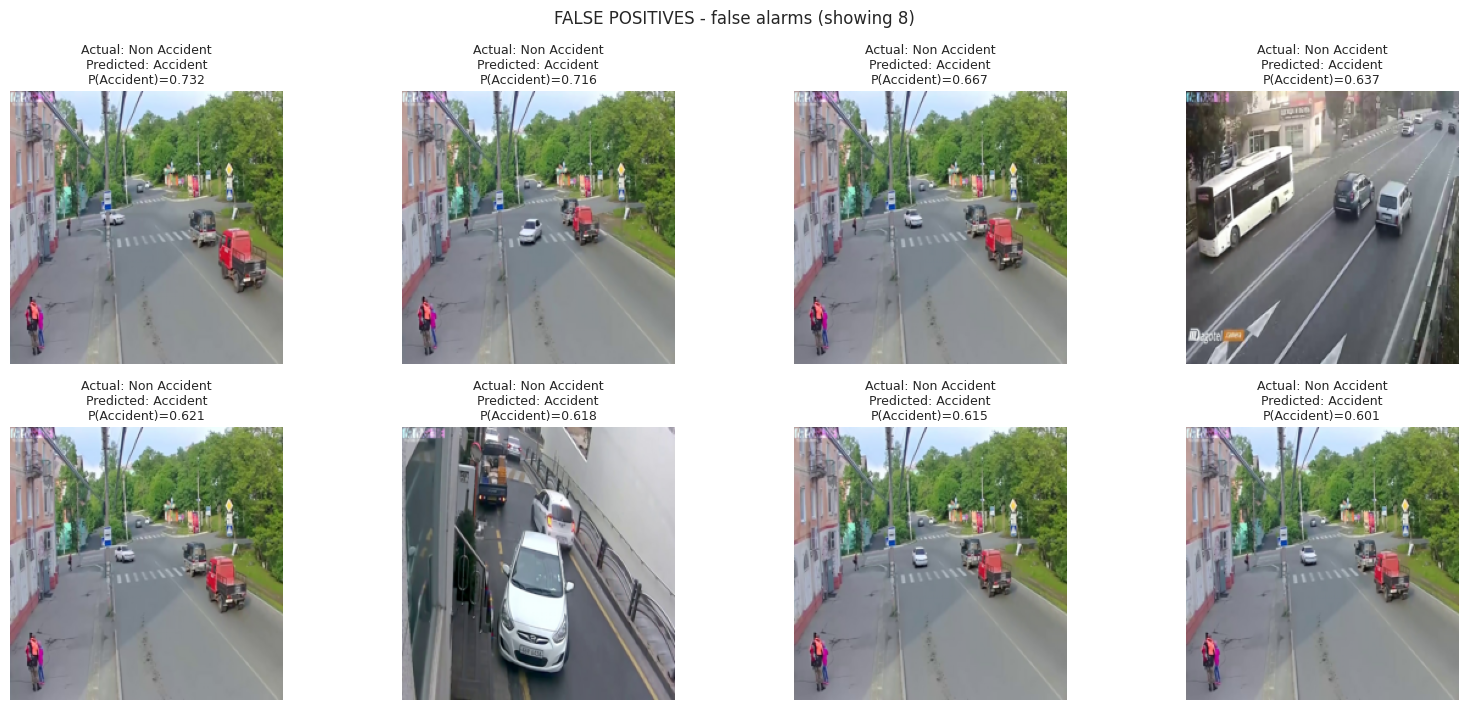

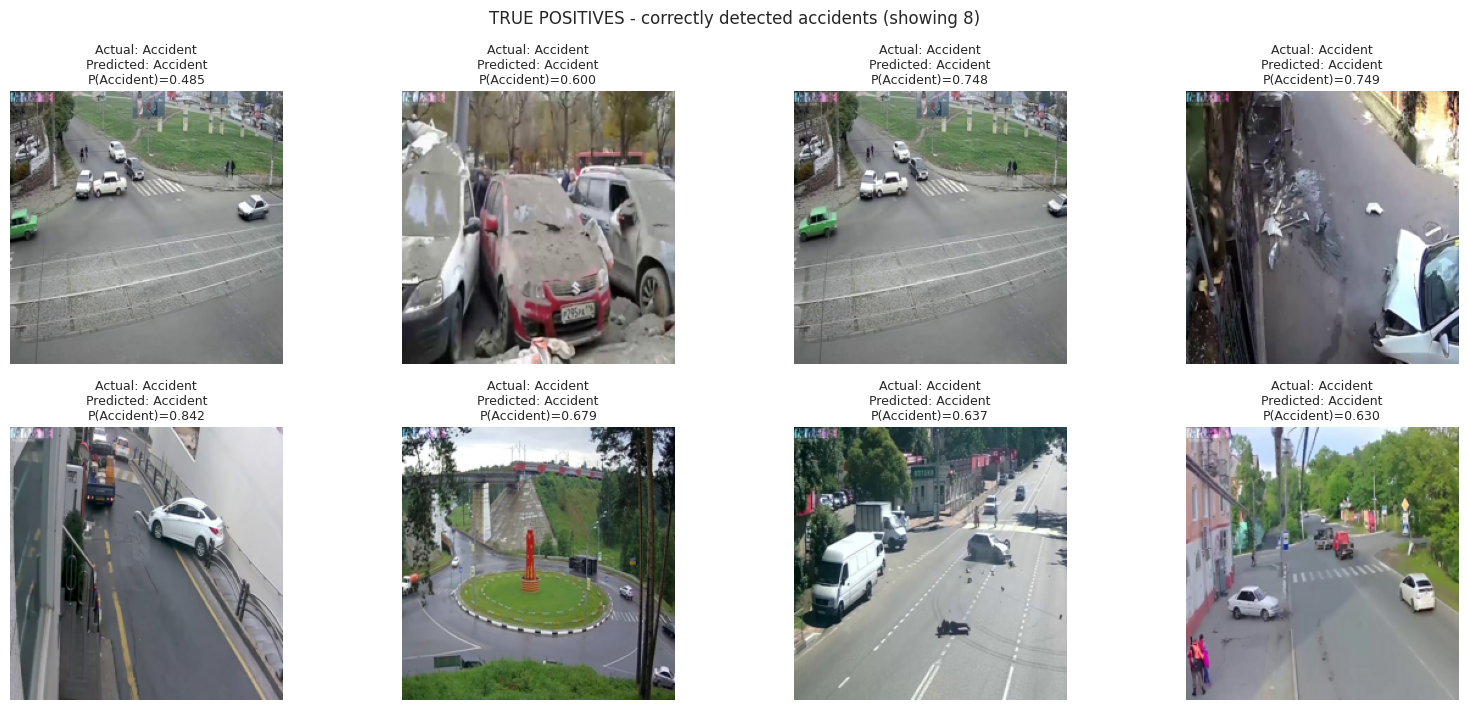

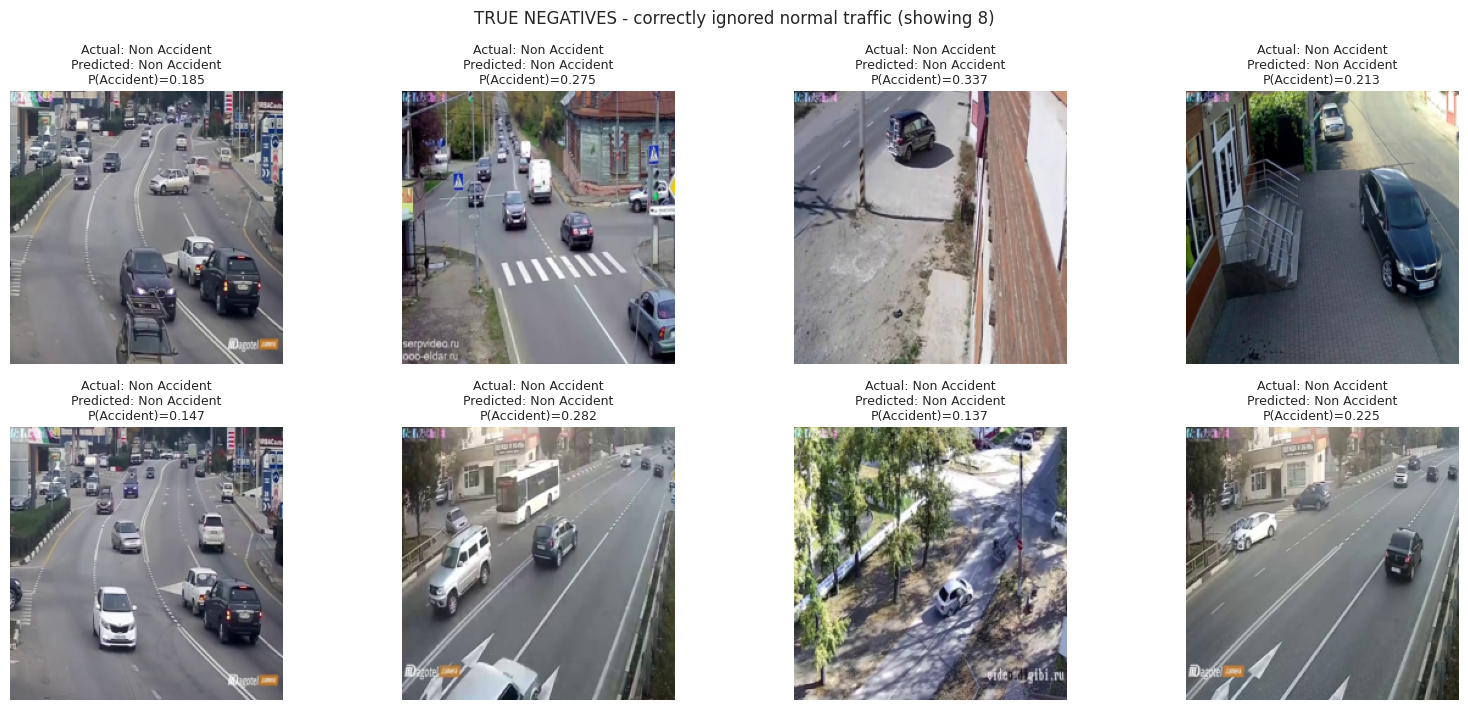

Saved annotated misclassified images to: /content/csrn_results/misclassified_images -> 33 files


In [ ]:
res_df = test_df[["path", "filename", "class_name", "label"]].copy()
res_df["accident_probability"] = test_probs
res_df["predicted"] = test_pred
res_df["predicted_name"] = res_df.predicted.map(IDX_TO_CLASS)

# Define conditions and string labels
conditions = [
    (res_df.label == 1) & (res_df.predicted == 1),  # True Positive
    (res_df.label == 0) & (res_df.predicted == 0),  # True Negative
    (res_df.label == 0) & (res_df.predicted == 1),  # False Positive
    (res_df.label == 1) & (res_df.predicted == 0)   # False Negative
]

choices = ["TP", "TN", "FP", "FN"]

# Pass default as a string ("Unknown") so all dtypes match
res_df["outcome"] = np.select(conditions, choices, default="Unknown")

res_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)
print(res_df.outcome.value_counts().to_dict())

def show_examples(df, title, n=8, ascending=None):
    if len(df) == 0:
        print(f"[{title}] none found."); return
    if ascending is not None:
        df = df.sort_values("accident_probability", ascending=ascending)
    else:
        df = df.sample(min(n, len(df)), random_state=SEED)
    df = df.head(n)
    cols = 4; rows = int(np.ceil(len(df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows)); axes = np.array(axes).reshape(-1)
    for ax in axes: ax.axis("off")
    for ax, r in zip(axes, df.itertuples()):
        ax.imshow(load_and_preprocess(r.path).numpy())
        ax.set_title(f"Actual: {r.class_name}\nPredicted: {r.predicted_name}\nP(Accident)={r.accident_probability:.3f}", fontsize=9)
    plt.suptitle(f"{title} (showing {len(df)})", fontsize=12); plt.tight_layout(); plt.show()

show_examples(res_df[res_df.outcome == "FN"], "FALSE NEGATIVES - missed accidents", ascending=True)     # lowest prob first
show_examples(res_df[res_df.outcome == "FP"], "FALSE POSITIVES - false alarms", ascending=False)       # highest prob first
show_examples(res_df[res_df.outcome == "TP"], "TRUE POSITIVES - correctly detected accidents")
show_examples(res_df[res_df.outcome == "TN"], "TRUE NEGATIVES - correctly ignored normal traffic")

# save annotated FP / FN images
def save_annotated(df, kind, max_n=50):
    for i, r in enumerate(df.head(max_n).itertuples()):
        im = cv2.imread(r.path)
        if im is None: continue
        scale = 640 / max(im.shape[:2]); im = cv2.resize(im, None, fx=scale, fy=scale)
        banner = np.full((60, im.shape[1], 3), 255, np.uint8)
        cv2.putText(banner, f"{kind} | actual={r.class_name} | pred={r.predicted_name}", (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)
        cv2.putText(banner, f"P(Accident)={r.accident_probability:.3f} thr={BEST_THRESHOLD:.2f}", (8, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 200), 1)
        cv2.imwrite(os.path.join(MISCLS_DIR, f"{kind}_{i:03d}_p{r.accident_probability:.2f}_{r.filename}"), np.vstack([banner, im]))

save_annotated(res_df[res_df.outcome == "FN"].sort_values("accident_probability"), "FN")
save_annotated(res_df[res_df.outcome == "FP"].sort_values("accident_probability", ascending=False), "FP")
print("Saved annotated misclassified images to:", MISCLS_DIR, "->", len(os.listdir(MISCLS_DIR)), "files")

Actual label: Accident


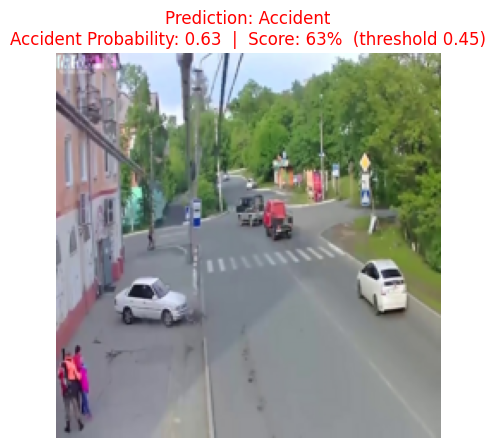

Prediction: Accident
Accident Probability: 0.63
Model score: 63%   (raw model output - not a calibrated real-world confidence)
ALERT: ACCIDENT SUSPECTED


In [ ]:
def predict_image(image_path, model_=None, threshold=None, show=True):
    model_ = model_ if model_ is not None else best_model
    threshold = BEST_THRESHOLD if threshold is None else threshold
    if not os.path.isfile(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    try:
        img = load_and_preprocess(tf.constant(image_path))          # same preprocessing as validation/test
    except Exception as e:
        raise ValueError(f"Could not read/decode image '{image_path}': {e}")
    prob = float(model_.predict(tf.expand_dims(img, 0), verbose=0)[0, 0])
    label = int(prob >= threshold)
    result = dict(path=image_path, predicted_label=label, predicted_class=IDX_TO_CLASS[label],
                  accident_probability=prob, threshold=threshold, alert=bool(label == 1))
    if show:
        plt.figure(figsize=(5.5, 5)); plt.imshow(img.numpy()); plt.axis("off")
        plt.title(f"Prediction: {result['predicted_class'].replace('_', '-')}\n"
                  f"Accident Probability: {prob:.2f}  |  Score: {prob*100:.0f}%  (threshold {threshold:.2f})",
                  color="red" if label == 1 else "green")
        plt.show()
        print(f"Prediction: {result['predicted_class']}")
        print(f"Accident Probability: {prob:.2f}")
        print(f"Model score: {prob*100:.0f}%   (raw model output - not a calibrated real-world confidence)")
        print("ALERT: ACCIDENT SUSPECTED" if result["alert"] else "No alert")
    return result

# demo on one random test image (replace with your own path to test other images)
demo_path = test_df.sample(1, random_state=SEED).path.iloc[0]
print("Actual label:", test_df[test_df.path == demo_path].class_name.iloc[0])
_ = predict_image(demo_path)

In [ ]:
ABLATION_CSV = os.path.join(OUTPUT_DIR, "ablation_results.csv")

def evaluate_checkpoint(m, tag):
    """Select threshold on VAL, report TEST metrics at that threshold. Returns a flat dict."""
    pv, pt = predict_probs(m, val_ds), predict_probs(m, test_ds)
    thr, _ = select_threshold(y_val, pv)
    r = metrics_at(y_test, pt, thr)
    p = count_parameters(m)
    return dict(variant=tag, description=VARIANT_DESCRIPTION.get(tag, tag), threshold=thr,
                accuracy=r["accuracy"], precision=r["precision"], recall=r["recall"], f1=r["f1"],
                roc_auc=safe_auc(y_test, pt), avg_precision=float(average_precision_score(y_test, pt)),
                fn=r["fn"], fp=r["fp"], parameters=p["total"], size_mb=p["size_mb"])

def save_ablation_row(row):
    df = pd.read_csv(ABLATION_CSV) if os.path.exists(ABLATION_CSV) else pd.DataFrame()
    if len(df) and "variant" in df:
        df = df[df.variant != row["variant"]]
    pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(ABLATION_CSV, index=False)

def run_variant(variant, epochs=ABLATION_EPOCHS):
    """Train one ablation variant from scratch, load its best-val checkpoint, evaluate, and save a result row."""
    assert variant in list(VARIANT_FLAGS) + ["SIMPLE"] and variant != "E", \
        "Use 'A','B','C','D' or 'SIMPLE'. Variant E is the main model trained above."
    print("=" * 70, f"\nRunning variant {variant}: {VARIANT_DESCRIPTION[variant]}\n" + "=" * 70)
    set_global_seed(SEED)
    m = build_by_name(variant)
    compile_model(m)
    cbs, ckpt, lr_log = make_callbacks(f"ablation_{variant}")
    hist = m.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs, verbose=2)
    m.load_weights(ckpt)                                   # best validation checkpoint
    row = evaluate_checkpoint(m, variant)
    save_ablation_row(row)
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})
    return row

if RUN_ABLATION:
    for v in ["A", "B", "C", "D", "SIMPLE"]:
        run_variant(v)
else:
    print("RUN_ABLATION=False -> nothing trained. Call run_variant('A'), run_variant('B'), ... individually when ready.")

RUN_ABLATION=False -> nothing trained. Call run_variant('A'), run_variant('B'), ... individually when ready.


In [ ]:
# Add the already-trained full CSRN (variant E) to the table, then display everything that has actually been run.
row_E = evaluate_checkpoint(best_model, "E")
save_ablation_row(row_E)

abl = pd.read_csv(ABLATION_CSV)
order = {"SIMPLE": 0, "A": 1, "B": 2, "C": 3, "D": 4, "E": 5}
abl = abl.sort_values("variant", key=lambda s: s.map(order)).reset_index(drop=True)
show_cols = ["variant", "description", "accuracy", "precision", "recall", "f1", "roc_auc", "fn", "fp", "parameters"]
print("ABLATION / BASELINE RESULTS (test set; threshold chosen on validation per model)")
print(abl[show_cols].round(4).to_string(index=False))
missing = [v for v in ["A", "B", "C", "D"] if v not in set(abl.variant)]
if missing:
    print("\nNot yet run:", missing, "-> run_variant('<name>')")

ABLATION / BASELINE RESULTS (test set; threshold chosen on validation per model)
variant description  accuracy  precision  recall     f1  roc_auc  fn  fp  parameters
      E   Full CSRN      0.67     0.6667  0.5957 0.6292   0.7503  19  14      423348

Not yet run: ['A', 'B', 'C', 'D'] -> run_variant('<name>')


In [ ]:
# ---- full model file (architecture + weights)
keras_path = os.path.join(OUTPUT_DIR, "best_csrn_model.keras")
try:
    best_model.save(keras_path)
    custom = {c.__name__: c for c in [ConvBNAct, MultiScaleFeatureModule, CollisionSensitiveModule,
                                      SpatialRelationModule, AttentionModule, FeatureFusionModule]}
    reloaded = keras.models.load_model(keras_path, custom_objects=custom, compile=False)
    x_chk = next(iter(test_ds))[0][:4]
    diff = float(np.max(np.abs(reloaded.predict(x_chk, verbose=0) - best_model.predict(x_chk, verbose=0))))
    print(f"Saved {keras_path} | reload self-test max |difference| = {diff:.2e}")
except Exception as e:
    print("Full .keras save/reload had a problem:", type(e).__name__, str(e)[:200])
    print("-> Use the weights file instead:", BEST_CKPT_PATH, "with build_csrn_model('E').load_weights(...)")
shutil.copy(BEST_CKPT_PATH, os.path.join(OUTPUT_DIR, "best_csrn.weights.h5"))

# ---- evaluation_results.csv (overall + per-class)
FINAL = dict(accuracy=mbest["accuracy"], precision=mbest["precision"], recall=mbest["recall"], f1=mbest["f1"],
             roc_auc=TEST_AUC, avg_precision=TEST_AP, threshold=BEST_THRESHOLD,
             tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
eval_rows = [dict(scope="overall", metric=k, value=v) for k, v in FINAL.items()]
for cname in CLASS_NAMES:
    for k in ["precision", "recall", "f1-score", "support"]:
        eval_rows.append(dict(scope=cname, metric=k, value=report_dict[cname][k]))
pd.DataFrame(eval_rows).to_csv(os.path.join(OUTPUT_DIR, "evaluation_results.csv"), index=False)

# ---- final_metrics.csv (one row: metrics + model info)
PARAMS = count_parameters(best_model)
pd.DataFrame([dict(model="CSRN", **FINAL, total_params=PARAMS["total"], trainable_params=PARAMS["trainable"],
                   non_trainable_params=PARAMS["non_trainable"], size_mb=PARAMS["size_mb"],
                   inference_ms_per_image_batch1=INF_MS_1, device=DEVICE, seed=SEED,
                   epochs_run=len(history.history["loss"]), best_epoch=BEST_EPOCH,
                   batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE)]).to_csv(
    os.path.join(OUTPUT_DIR, "final_metrics.csv"), index=False)

print("\nFiles in", OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("  ", f + ("/" if os.path.isdir(os.path.join(OUTPUT_DIR, f)) else ""))

zip_path = shutil.make_archive("/content/csrn_results_bundle", "zip", OUTPUT_DIR)
print("Zip bundle:", zip_path)
if COPY_RESULTS_TO_DRIVE and os.path.isdir("/content/drive/MyDrive"):
    shutil.copytree(OUTPUT_DIR, DRIVE_RESULTS_DIR, dirs_exist_ok=True)
    print("Copied results to Google Drive:", DRIVE_RESULTS_DIR)

Saved /content/csrn_results/best_csrn_model.keras | reload self-test max |difference| = 0.00e+00

Files in /content/csrn_results
   ablation_results.csv
   architecture.png
   architecture_keras_plot.png
   best_csrn.weights.h5
   best_csrn_model.keras
   checkpoints/
   confusion_matrix.png
   evaluation_results.csv
   final_metrics.csv
   misclassified_images/
   precision_recall_curve.png
   roc_curve.png
   test_predictions.csv
   threshold_analysis.png
   threshold_results.csv
   threshold_results_validation.csv
   training_history.png
Zip bundle: /content/csrn_results_bundle.zip
Copied results to Google Drive: /content/drive/MyDrive/csrn_results


In [ ]:
PARAMS = count_parameters(best_model)
print("CSRN MODEL RESULTS")
print("------------------")
print(f"Test Accuracy : {FINAL['accuracy']:.4f}")
print(f"Precision     : {FINAL['precision']:.4f}   (Accident class)")
print(f"Recall        : {FINAL['recall']:.4f}   (Accident class)")
print(f"F1-Score      : {FINAL['f1']:.4f}   (Accident class)")
print(f"ROC-AUC       : {FINAL['roc_auc']:.4f}")
print(f"Avg Precision : {FINAL['avg_precision']:.4f}")
print()
print(f"Total Parameters     : {PARAMS['total']:,}")
print(f"Trainable Parameters : {PARAMS['trainable']:,}")
print(f"Model Size           : {PARAMS['size_mb']:.2f} MB (float32)")
print(f"Inference time       : {INF_MS_1:.1f} ms/image on {DEVICE} (batch=1)")
print()
print(f"Best Threshold       : {BEST_THRESHOLD:.2f}  (chosen on validation, metric={THRESHOLD_METRIC})")
print(f"Best epoch           : {BEST_EPOCH} of {len(history.history['loss'])} run")

print("\nAUTOMATIC INTERPRETATION (rule-based, from the numbers above)")
print("-" * 62)
n_acc, n_non = int((y_test == 1).sum()), int((y_test == 0).sum())
print(f"* On {len(y_test)} test images ({n_acc} accident / {n_non} non-accident), CSRN reached "
      f"accuracy {FINAL['accuracy']:.3f} and ROC-AUC {FINAL['roc_auc']:.3f} at threshold {BEST_THRESHOLD:.2f}.")
print(f"* It missed {fn} of {n_acc} accident images (recall {FINAL['recall']:.3f}) and raised {fp} false alarms among "
      f"{n_non} normal images (precision {FINAL['precision']:.3f}).")
if FINAL["recall"] < FINAL["precision"]:
    print("* Recall is lower than precision: the system favours fewer false alarms over catching every accident. "
          "For emergency alerting consider a lower threshold (or THRESHOLD_METRIC='f2') and re-validate.")
else:
    print("* Recall is at least as high as precision: the system leans towards catching accidents, at the cost of some false alarms.")
if GAP_ACC > 0.10:
    print(f"* At the best epoch training accuracy exceeds validation accuracy by {GAP_ACC:.3f}: some overfitting is likely.")
n_total_test = len(y_test)
if n_total_test < 500:
    print(f"* The test set is small ({n_total_test} images): metrics have wide uncertainty; avoid over-interpreting small differences.")
if os.path.exists(ABLATION_CSV):
    ab = pd.read_csv(ABLATION_CSV).set_index("variant")
    base_name = "A" if "A" in ab.index else ("SIMPLE" if "SIMPLE" in ab.index else None)
    if base_name and "E" in ab.index:
        dF1 = ab.loc["E", "f1"] - ab.loc[base_name, "f1"]; dAUC = ab.loc["E", "roc_auc"] - ab.loc[base_name, "roc_auc"]
        print(f"* Versus baseline '{base_name}' (single run each): F1 {dF1:+.4f}, ROC-AUC {dAUC:+.4f}. "
              "A difference from one run/seed is not proof that the modules help; repeat with several seeds before claiming it.")
    else:
        print("* No baseline run found yet -> no claim is made about whether the CSRN modules improve performance. Run Section 31.")
print("* No comparison with published methods was performed, so no state-of-the-art claim is made.")
print("* Results are valid only for this dataset/split; check the near-duplicate report (Section 6b) and test on new, "
      "independent footage before any real-world deployment.")

CSRN MODEL RESULTS
------------------
Test Accuracy : 0.6700
Precision     : 0.6667   (Accident class)
Recall        : 0.5957   (Accident class)
F1-Score      : 0.6292   (Accident class)
ROC-AUC       : 0.7503
Avg Precision : 0.7260

Total Parameters     : 423,348
Trainable Parameters : 418,804
Model Size           : 1.61 MB (float32)
Inference time       : 237.9 ms/image on GPU (batch=1)

Best Threshold       : 0.45  (chosen on validation, metric=f1)
Best epoch           : 26 of 30 run

AUTOMATIC INTERPRETATION (rule-based, from the numbers above)
--------------------------------------------------------------
* On 100 test images (47 accident / 53 non-accident), CSRN reached accuracy 0.670 and ROC-AUC 0.750 at threshold 0.45.
* It missed 19 of 47 accident images (recall 0.596) and raised 14 false alarms among 53 normal images (precision 0.667).
* Recall is lower than precision: the system favours fewer false alarms over catching every accident. For emergency alerting consider a lower 